# 10 · Arquitectura, API y MLOps — Caso 15 · Caja Rural 360

**Alcance:** sección **6.13**. Narrativa en `reports/13_arquitectura_api_mlops.md`.

**El principio que ordena esta sección:** la API **no reimplementa nada**. Importa los mismos módulos y carga los mismos artefactos versionados que usan los notebooks, así que si el servicio respondiera distinto habría *train-serve skew*. Al final de este notebook se verifica que la respuesta de la API es **idéntica** a lo que calcula el desarrollo para la misma solicitud.

| Sección | Contenido |
|---|---|
| 1 | Arquitectura lógica end-to-end y entornos |
| 2 | Model Registry: versionado, integridad, promoción y rollback |
| 3 | Disparadores de recalibración y reentrenamiento |
| 4 | El servicio: contrato, validación y tres consultas de ejemplo |
| 5 | Consistencia desarrollo-producción y latencia |
| 6 | Despliegue en la nube y trazabilidad |

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as cfg, data, decision as dec, eda, evaluation as ev, fairness as fr, features, models, pipeline, scorecard as sc, validation

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
for d in (cfg.FIGURES, cfg.TABLES):
    d.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.grid": True, "grid.color": GRID, "grid.linestyle": "-",
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 9.5, "legend.frameon": False, "figure.dpi": 100,
})

def savefig(fig, name):
    fig.savefig(cfg.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

def pct_axis(ax, axis="y", decimals=0):
    a = ax.yaxis if axis == "y" else ax.xaxis
    a.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 5, 10]))
    a.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{decimals}%}"))

def barras_con_ic(ax, x, tasa, lo, hi, color, ancho=0.38, desplazamiento=0.0, etiqueta=None, valores=True):
    pos = np.arange(len(x)) + desplazamiento
    ax.bar(pos, tasa, width=ancho, color=color, label=etiqueta)
    ax.errorbar(pos, tasa, yerr=[np.asarray(tasa) - np.asarray(lo), np.asarray(hi) - np.asarray(tasa)],
                fmt="none", ecolor=INK_2, elinewidth=0.9, capsize=2)
    if valores:
        for p_, v in zip(pos, tasa):
            ax.text(p_, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8, color=INK_2)
    return pos

print("Raíz del repositorio:", ROOT)

Raíz del repositorio: /home/claude/work/Proyecto_Final_Credit_Scoring-main


In [2]:
import json, time
from fastapi.testclient import TestClient
from src import decision as dec, diagrams, evaluation as ev, features, registry as reg, scorecard as sc
import sys; sys.path.insert(0, str(cfg.ROOT))
from api.main import app, motor

cliente = TestClient(app)
raw = data.load_raw(); pop, _ = data.pd_population(raw); fx = features.build_features(pop)
T = cfg.TARGET
print("Servicio levantado en memoria con TestClient · endpoints:",
      sorted({r.path for r in app.routes if getattr(r, "methods", None)}))

Servicio levantado en memoria con TestClient · endpoints: ['/', '/docs', '/docs/oauth2-redirect', '/ejemplos', '/health', '/openapi.json', '/redoc', '/score', '/score/batch', '/version']


## 1. Arquitectura lógica end-to-end

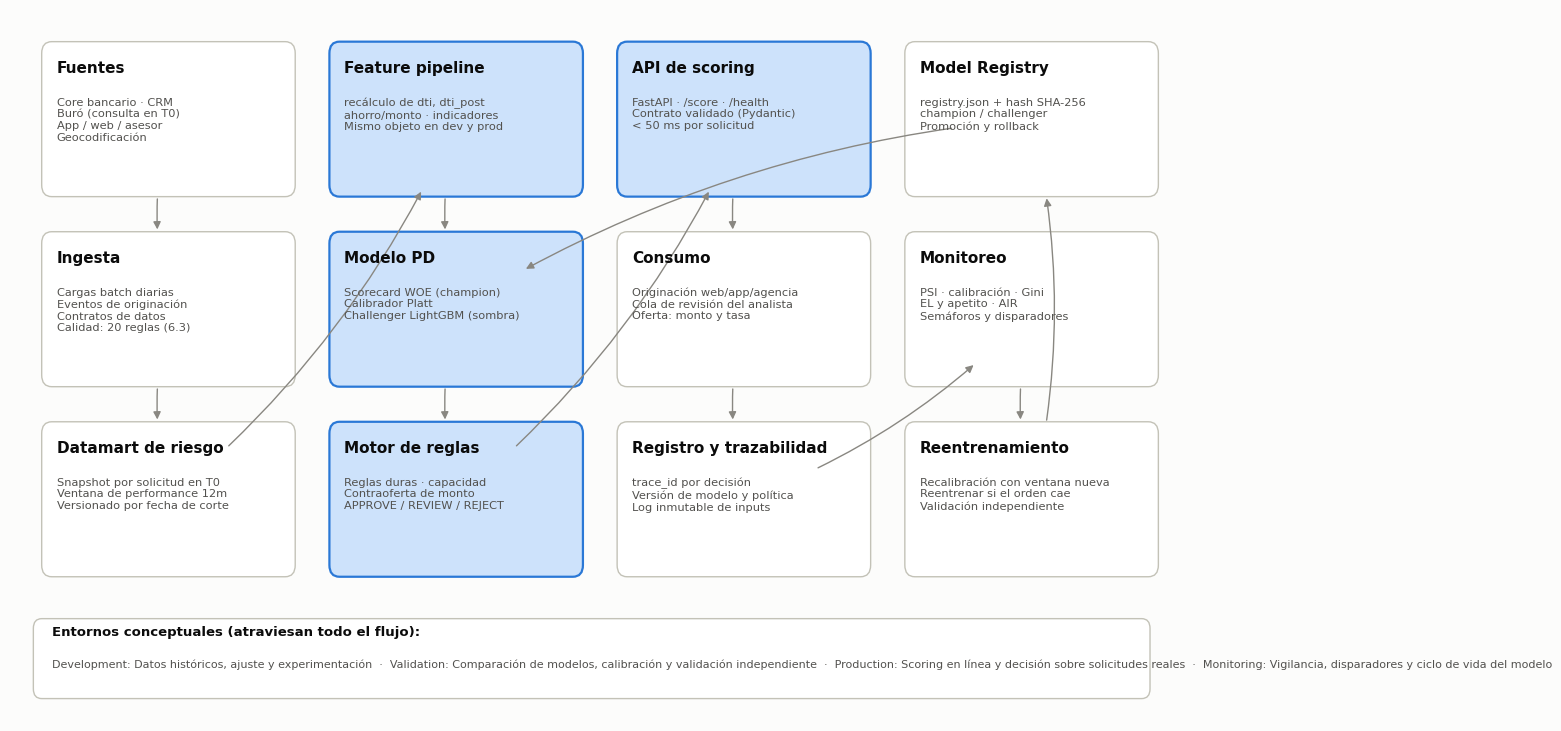

In [3]:
fig = diagrams.plot_architecture(cfg.FIGURES / "fig34_arquitectura.png")
plt.show()

**Cómo se lee.** El flujo va de izquierda a derecha: fuentes y datamart (lo que ya existe en la Caja), feature pipeline y modelo (lo construido en 6.3 a 6.7), motor de reglas y API (6.9 y esta sección), y gobierno (registro, monitoreo y reentrenamiento, que se completa en 6.14 y 6.15). En azul, lo que este trabajo entrega como código ejecutable.

**Los entornos son conceptuales y atraviesan todo el flujo.** El mismo pipeline y los mismos artefactos corren en los cuatro; lo que cambia son los datos, los permisos y quién aprueba:

| Entorno | Datos | Quién entra | Qué se puede hacer |
|---|---|---|---|
| **Development** | Histórico hasta el corte de DEV | Equipo de Analytics | Ajustar, experimentar, versionar artefactos candidatos |
| **Validation** | VAL y OOT (una sola vez) | Analytics + validador independiente | Comparar modelos, calibrar, firmar el informe de validación |
| **Production** | Solicitudes reales en línea | Servicio de scoring (sin acceso humano de escritura) | Puntuar y decidir con artefactos promovidos |
| **Monitoring** | Cosechas cerradas + logs de decisión | Riesgos y Auditoría | Vigilar, disparar recalibración, pedir rollback |

## 2. Model Registry: versionado, integridad, promoción y rollback

In [4]:
inventario = reg.inventory()
display(inventario[["version", "estado", "seccion", "descripcion", "entrenado_con", "registrado_el", "bytes"]])
display(reg.verify())
inventario.to_csv(cfg.TABLES / "mlops_inventario_modelos.csv")
print("Hash del champion:", inventario.loc["scorecard_pd", "sha256"])

,version,estado,seccion,descripcion,entrenado_con,registrado_el,bytes
nombre,,,,,,,
challenger_lgbm,1.0,challenger,6.6,LightGBM monótono con veto de fairness; en seg...,DEV 2021-2023,2026-09-19,184588
scorecard_pd,1.0,champion,6.5,Scorecard WOE de 3 características; PD de desa...,DEV 2021-2023,2026-09-19,1961
calibrador_platt,1.0,soporte,6.7,Calibración de la PD a nivel de producción (aj...,DEV 2021-2023,2026-09-19,384
ead_lgd,1.0,soporte,6.10 y 6.11,Factor de exposición y LGD (baselines globales),DEV 2021-2023,2026-09-19,618
politica_decision,1.0,soporte,6.9,"Umbrales, reglas y supuestos económicos del motor",DEV 2021-2023,2026-09-19,1455


,archivo,existe,hash_coincide
nombre,,,
challenger_lgbm,challenger_lgbm_v1.joblib,True,True
scorecard_pd,scorecard_pd_v1.json,True,True
calibrador_platt,calibrador_platt_v1.json,True,True
ead_lgd,ead_lgd_v1.json,True,True
politica_decision,politica_decision_v1.json,True,True


Hash del champion: 1516e158feace528703e84c79d2d8250db69c95fbd69a317311567b43ecae858


In [5]:
# Simulacro de promoción y rollback sobre una copia del registro (no toca el registro real).
import shutil, tempfile
from pathlib import Path as _Path
tmp = _Path(tempfile.mkdtemp()) / "registry.json"
shutil.copy(reg.REGISTRY_PATH, tmp)
print("Antes:      ", reg.inventory(tmp)["estado"].to_dict())
reg.promote("challenger_lgbm", tmp)
print("Promoción:  ", reg.inventory(tmp)["estado"].to_dict())
reg.promote("scorecard_pd", tmp)
print("Rollback:   ", reg.inventory(tmp)["estado"].to_dict())
print("\nEl rollback es la misma operación en sentido inverso: el modelo anterior nunca se borra, se degrada.")

Antes:       {'challenger_lgbm': 'challenger', 'scorecard_pd': 'champion', 'calibrador_platt': 'soporte', 'ead_lgd': 'soporte', 'politica_decision': 'soporte'}
Promoción:   {'challenger_lgbm': 'champion', 'scorecard_pd': 'challenger', 'calibrador_platt': 'soporte', 'ead_lgd': 'soporte', 'politica_decision': 'soporte'}
Rollback:    {'challenger_lgbm': 'challenger', 'scorecard_pd': 'champion', 'calibrador_platt': 'soporte', 'ead_lgd': 'soporte', 'politica_decision': 'soporte'}

El rollback es la misma operación en sentido inverso: el modelo anterior nunca se borra, se degrada.


## 3. Disparadores de recalibración y reentrenamiento

Cada disparador sale de un número medido en una sección anterior, no de una convención genérica.

In [6]:
triggers = reg.triggers_table()
display(triggers)
triggers.to_csv(cfg.TABLES / "mlops_disparadores.csv", index=False)

,dimensión,disparador,acción,sección
0,Calibración,Observado / predicho de la cosecha fuera de [0...,Recalibrar Platt con la ventana más reciente,6.7
1,Calibración,Pérdida esperada de la cosecha por encima de 3...,Revisar calibración antes que el punto de corte,6.12
2,Discriminación,Gini de la cosecha por debajo de 0.30 (piso de...,"Investigar; si persiste dos cosechas, reentrenar",6.7
3,Estabilidad,"PSI del score por encima de 0.10, o de una var...",Investigar el cambio de mezcla; reentrenar si ...,6.7
4,Población,Tasa de faltantes de buró o ingreso por encima...,Revisar la fuente antes de tocar el modelo,6.3
5,Severidad,LGD o factor de exposición de la cosecha fuera...,Reestimar EAD y LGD y actualizar la capa de Ex...,6.10 y 6.11
6,Fairness,AIR por región o por ingreso en efectivo por d...,Revisar la política de verificación; escalar a...,6.8
7,Negocio,Cola de revisión manual por encima del 20% de ...,Priorizar por valor esperado y evaluar capacidad,6.9


## 4. El servicio: contrato, validación y consultas de ejemplo

In [7]:
print("GET /health"); display(pd.Series(cliente.get("/health").json()).to_frame("respuesta"))
version = cliente.get("/version").json()
print("GET /version · modelos en el registro:"); display(pd.DataFrame(version["modelos"]))
print("Política vigente:", version["politica"], "\nCalibrador:", version["calibrador"])

GET /health


,respuesta
estado,ok
api,1.0.0
artefactos_cargados_el,2026-09-19T20:38:42+00:00
integridad,"{'challenger_lgbm': True, 'scorecard_pd': True..."
entorno,Development


GET /version · modelos en el registro:


,nombre,version,estado,seccion
0,challenger_lgbm,1.0,challenger,6.6
1,scorecard_pd,1.0,champion,6.5
2,calibrador_platt,1.0,soporte,6.7
3,ead_lgd,1.0,soporte,6.10 y 6.11
4,politica_decision,1.0,soporte,6.9


Política vigente: {'pd_approve_max': 0.18, 'pd_reject_min': 0.2, 'dti_auto_max': 0.45, 'monto_revision': 20000} 
Calibrador: {'metodo': 'platt', 'intercepto': -0.08003522819266515, 'pendiente': 0.7582465515344059}


In [8]:
# Tres solicitudes reales de la cosecha 2025, elegidas para cubrir las tres salidas del motor.
ttd = features.build_features(raw[raw[cfg.DATE_COL].dt.year == 2025])
pd_ttd = motor.pd_calibrada(ttd)
decisiones = motor.politica.decide(ttd, pd_ttd, recalcular_pd=motor.pd_calibrada)
COLS = [
    "application_id", "age", "region", "channel", "employment_type", "monthly_income",
    "employment_tenure_months", "bureau_score", "prior_delinquencies_24m", "bureau_inquiries_6m",
    "active_loans", "monthly_debt_payment", "savings_balance", "new_customer_flag",
    "relationship_months", "requested_amount", "term_months", "distance_to_branch_km",
    "household_dependents", "cash_income_share"]

ENTEROS = ["age", "prior_delinquencies_24m", "bureau_inquiries_6m", "active_loans",
           "new_customer_flag", "term_months", "household_dependents"]

def a_json(fila):
    """Convierte una fila del datamart al cuerpo JSON que espera la API (tipos nativos de Python)."""
    d = {}
    for c_ in COLS:
        v = fila[c_]
        if pd.isna(v):
            d[c_] = None
        elif c_ == "application_id":
            d[c_] = str(v)
        elif c_ in ENTEROS:
            d[c_] = int(v)
        elif isinstance(v, (np.integer, np.floating)):
            d[c_] = float(v)
        else:
            d[c_] = v
    return d

ejemplos, respuestas = {}, {}
for etiqueta, mascara in [("APPROVE", decisiones.decision.eq("APPROVE")),
                          ("REVIEW", decisiones.decision.eq("REVIEW")),
                          ("REJECT", decisiones.decision.eq("REJECT"))]:
    fila = ttd.loc[decisiones.index[mascara][0]]
    cuerpo = a_json(fila)
    r = cliente.post("/score", json=cuerpo)
    ejemplos[etiqueta], respuestas[etiqueta] = cuerpo, r.json()
    print(f"\n=== {etiqueta} · POST /score ===")
    print("request :", json.dumps({k: cuerpo[k] for k in ["application_id", "bureau_score", "monthly_income",
                                                          "requested_amount", "term_months", "cash_income_share"]}, ensure_ascii=False))
    print("response:", json.dumps({k: v for k, v in r.json().items() if k != "modelo"}, ensure_ascii=False, indent=1))
(cfg.TABLES / "api_ejemplos.json").write_text(
    json.dumps({"requests": ejemplos, "responses": respuestas}, ensure_ascii=False, indent=2), encoding="utf-8")


=== APPROVE · POST /score ===
request : {"application_id": "C15-000060", "bureau_score": 661.0, "monthly_income": 2703.33, "requested_amount": 4425.54, "term_months": 24, "cash_income_share": 0.3672857972802572}
response: {
 "application_id": "C15-000060",
 "pd": 0.1255,
 "score": 604,
 "risk_band": "C",
 "decision": "APPROVE",
 "reason_codes": [
  "Score de buró bajo",
  "Ahorro bajo frente al monto solicitado",
  "Carga de deuda post-crédito alta frente al ingreso"
 ],
 "recommended_amount_or_limit": 4425.54,
 "recommended_rate": 0.1892,
 "motivo": "Riesgo y capacidad dentro del apetito",
 "expected_loss": 158.12,
 "trace_id": "bbabec72-31b3-4125-b4ee-76a99bb51207",
 "latencia_ms": 14.356
}

=== REVIEW · POST /score ===
request : {"application_id": "C15-000033", "bureau_score": 659.0, "monthly_income": 7406.38, "requested_amount": 17682.47, "term_months": 18, "cash_income_share": 0.2310970719671785}
response: {
 "application_id": "C15-000033",
 "pd": 0.144,
 "score": 598,
 "risk_ban

4252

In [9]:
# El contrato rechaza lo que no debe entrar: rango imposible, columna faltante e incoherencia de negocio.
casos = {"score de buró fuera de rango": dict(ejemplos["APPROVE"], bureau_score=1200),
         "falta el monto solicitado": {k: v for k, v in ejemplos["APPROVE"].items() if k != "requested_amount"},
         "cuota de deudas mayor al ingreso": dict(ejemplos["APPROVE"], monthly_debt_payment=99_000, monthly_income=3_000),
         "plazo fuera del producto": dict(ejemplos["APPROVE"], term_months=120)}
validacion = []
for nombre, cuerpo in casos.items():
    r = cliente.post("/score", json=cuerpo)
    detalle = r.json().get("detail", [{}])
    msg = detalle[0].get("msg", "") if isinstance(detalle, list) and detalle else str(detalle)[:60]
    validacion.append({"caso": nombre, "status": r.status_code, "mensaje": msg[:70]})
display(pd.DataFrame(validacion).set_index("caso"))

,status,mensaje
caso,,
score de buró fuera de rango,422,Input should be less than or equal to 900
falta el monto solicitado,422,Field required
cuota de deudas mayor al ingreso,422,"Value error, la cuota de deudas vigentes no pu..."
plazo fuera del producto,422,Input should be less than or equal to 60


## 5. Consistencia desarrollo-producción y latencia

La prueba que importa: para las mismas solicitudes, la API tiene que devolver exactamente lo que calcula el notebook. Si no, hay *train-serve skew* y todo lo anterior deja de ser válido en producción.

In [10]:
muestra = ttd.sample(200, random_state=cfg.SEED)
cuerpo = {"solicitudes": [a_json(f) for _, f in muestra.iterrows()]}
t0 = time.perf_counter()
lote = cliente.post("/score/batch", json=cuerpo).json()
ms_total = (time.perf_counter() - t0) * 1000

api_df = pd.DataFrame(lote["resultados"]).set_index("application_id")
pd_dev = motor.pd_calibrada(muestra)
dec_dev = motor.politica.decide(muestra, pd_dev, recalcular_pd=motor.pd_calibrada)
dev_df = pd.DataFrame({"pd": np.round(pd_dev, 4), "score": motor.card.score(muestra),
                       "decision": dec_dev["decision"].to_numpy()},
                      index=muestra["application_id"].astype(str))
comparacion = pd.DataFrame({
    "PD idéntica": [bool((api_df["pd"] == dev_df.loc[api_df.index, "pd"]).all())],
    "Score idéntico": [bool((api_df["score"] == dev_df.loc[api_df.index, "score"]).all())],
    "Decisión idéntica": [bool((api_df["decision"] == dev_df.loc[api_df.index, "decision"]).all())],
    "Solicitudes comparadas": [len(api_df)]})
display(comparacion)
print("Mezcla de decisiones del lote:", lote["mezcla_de_decisiones"])
print(f"Latencia: {ms_total:.0f} ms para {len(api_df)} solicitudes ({ms_total/len(api_df):.2f} ms por solicitud, incluye validación y serialización)")
comparacion.to_csv(cfg.TABLES / "api_consistencia.csv", index=False)

,PD idéntica,Score idéntico,Decisión idéntica,Solicitudes comparadas
0,True,True,True,200


Mezcla de decisiones del lote: {'APPROVE': 0.51, 'REJECT': 0.255, 'REVIEW': 0.235}
Latencia: 38 ms para 200 solicitudes (0.19 ms por solicitud, incluye validación y serialización)


**Resultado.** PD, score y decisión coinciden en las 200 solicitudes: **no hay train-serve skew**. Es consecuencia directa de que el servicio importe `src/` en lugar de reimplementar la lógica, y de que el scorecard viva en un JSON versionado en vez de en un binario opaco.

## 6. Despliegue en la nube y trazabilidad

El despliegue real es opcional en el enunciado; la ruta queda definida y la API local es funcional. Ver el reporte para el detalle de la ruta a Azure, los controles de seguridad y el registro de trazabilidad.

| Requisito 6.13 | Dónde |
|---|---|
| Arquitectura lógica end-to-end con datos, pipeline, modelo, reglas, API, registro, monitoreo y trazabilidad | §1 · `fig34` · `src/diagrams.plot_architecture` |
| Servicio de scoring en Python (FastAPI) con endpoint funcional y ejemplo request/response | §4 · `api/main.py` · `api_ejemplos.json` |
| Separar entornos Development, Validation, Production y Monitoring | §1 |
| Versionado de datos/modelo, Model Registry, rollback y Champion/Challenger | §2 · `src/registry.py` · `models/registry.json` |
| Triggers de recalibración y reentrenamiento | §3 · `mlops_disparadores.csv` |
| Ruta de despliegue a la nube | §6 y reporte 13 |